<a href="https://colab.research.google.com/github/Kamindumenula/SE4050-Household-Waste-Classification-System/blob/main/resnet50/IT23293908resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


#DOWNLOAD & EXTRACT DATASET

if not os.path.exists("SE4050-Household-Waste-Classification-System"):
    !git clone https://github.com/Kamindumenula/SE4050-Household-Waste-Classification-System.git

DATASET_DIR = "/content/dataset-resized"
if not os.path.exists(DATASET_DIR):
    !unzip -q -o SE4050-Household-Waste-Classification-System/dataset/archive.zip -d /content/


# LOAD & SPLIT (80% TRAIN, 10% VAL, 10% TEST)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load 80% for training
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load 20% held-out
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split the 20% into 10% val and 10% test
val_size = int(len(val_test_ds) * 0.5)
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

# APPLY COMMON DATA AUGMENTATION (ONLY TO TRAIN DATASET!)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),  # Flips left/right
    layers.RandomRotation(0.15),      # Rotates ±15%
    layers.RandomZoom(0.15),          # Zooms in/out ±15%
    layers.RandomContrast(0.1),       # Slight lighting change
], name="common_data_augmentation")

# We apply augmentation directly to train_ds:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)


# SPEED OPTIMIZATION (CACHE & PREFETCH)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

classes = sorted(os.listdir(DATASET_DIR))
print(f"Setup Complete!")
print(f"Classes ({len(classes)}): {classes}")
print(f"Batches -> Train: {len(train_ds)} (Augmented) | Val: {len(val_ds)} | Test: {len(test_ds)}")

Cloning into 'SE4050-Household-Waste-Classification-System'...
remote: Enumerating objects: 343, done.
remote: Counting objects: 100% (268/268), done.
remote: Compressing objects: 100% (198/198), done.
remote: Total 343 (delta 132), reused 153 (delta 67), pack-reused 75 (from 1)
Receiving objects: 100% (343/343), 83.85 MiB | 27.28 MiB/s, done.
Resolving deltas: 100% (144/144), done.
Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Setup Complete!
Classes (6): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Batches -> Train: 64 (Augmented) | Val: 8 | Test: 8


In [3]:
from tensorflow.keras.applications import ResNet50

# Load ResNet50 model without the top layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base layers
base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
from tensorflow.keras import layers
from tensorflow import keras

NUM_CLASSES = 6

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [5]:
# 1. Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Train the Model
epochs = 10
print("Training started...")
history = model.fit(
    train_ds,                  # Your training data variable
    validation_data=val_ds,    # Your validation data variable
    epochs=epochs
)

# 3. Save the Model in Colab
model.save('IT23293908ResNet50.keras')
print("Model saved successfully!")

Training started...
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 455s 7s/step - accuracy: 0.6711 - loss: 0.9168 - val_accuracy: 0.7656 - val_loss: 0.6505
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 437s 7s/step - accuracy: 0.7849 - loss: 0.5703 - val_accuracy: 0.7969 - val_loss: 0.6137
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 437s 7s/step - accuracy: 0.8492 - loss: 0.4337 - val_accuracy: 0.7852 - val_loss: 0.5766
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 471s 7s/step - accuracy: 0.8675 - loss: 0.3623 - val_accuracy: 0.8125 - val_loss: 0.5030
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 434s 7s/step - accuracy: 0.8764 - loss: 0.3353 - val_accuracy: 0.8281 - val_loss: 0.5072
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 445s 7s/step - accuracy: 0.9090 - loss: 0.2739 - val_accuracy: 0.8281 - val_loss: 0.4935
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 434s 7s/step - accuracy: 0.9060 - loss: 0.2458 - val_accuracy: 0.8398 - val_loss: 0.4864
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 431s 7s/step - accuracy: 0.9149 - loss: 0.2251 - val_

Evaluating on Test Dataset...
8/8 ━━━━━━━━━━━━━━━━━━━━ 47s 6s/step - accuracy: 0.8715 - loss: 0.5334
Final Test Accuracy: 0.8715


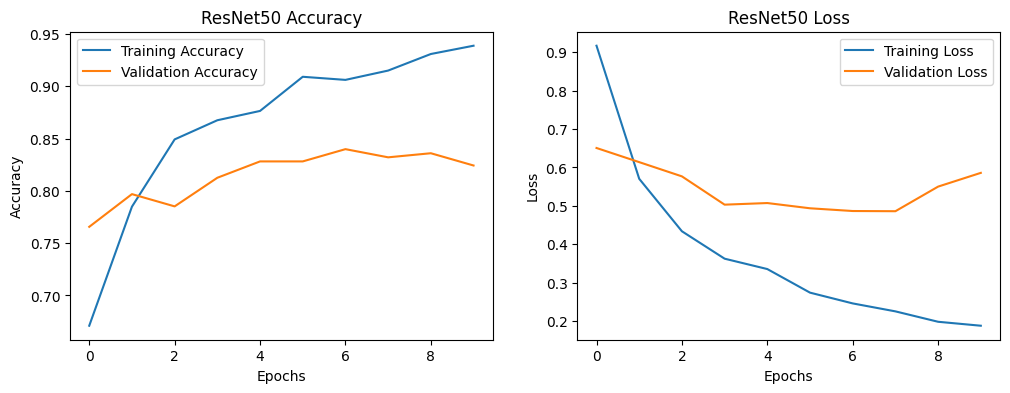

In [6]:
import matplotlib.pyplot as plt

# 1. Evaluate the model on the unseen test dataset
print("Evaluating on Test Dataset...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Final Test Accuracy: {test_acc:.4f}")

# 2. Plot Accuracy and Loss Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('ResNet50 Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('ResNet50 Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

# 3. Save the graph as an image file
plt.savefig('IT23293908_resnet50_learning_curves.png')
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 51s 6s/step


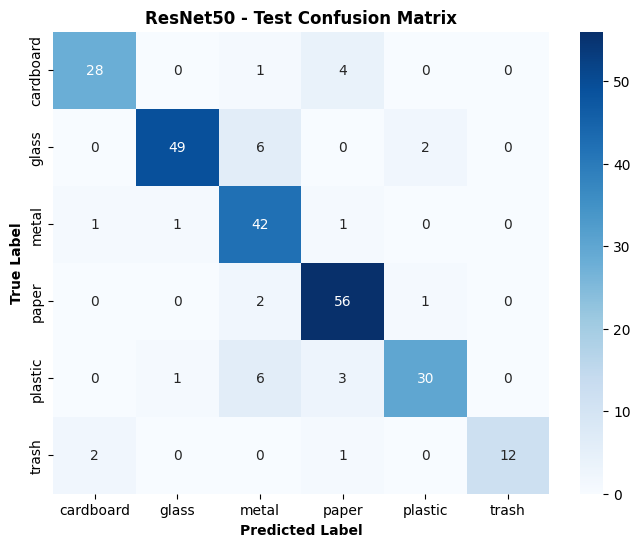

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict on test dataset
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

# Extract ground truth labels
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Generate and save confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('ResNet50 - Test Confusion Matrix', fontweight='bold')
plt.savefig('IT23293908_resnet50_confusion_matrix.png', dpi=300)
plt.show()